# Flight Fare Prediction - Pipeline Orchestration

This notebook provides an interactive interface to run the end-to-end Machine Learning pipeline for flight fare prediction. It uses the modularized code structure from the `src` directory to execute each step of the pipeline.

## Pipeline Setup
First, we set up the environment and imports.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Add project root to path to import src modules
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Change working directory to project root for correct file paths
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

# Imports from src
from src.config import config
from src.utils.logger import get_logger
from src.utils.helpers import set_random_seed
from src.data import DataLoader, DataPreprocessor
from src.features import FeatureEngineer
from src.eda import EDAAnalyzer
from src.models import ModelTrainer
from src.evaluation import ModelEvaluator
from src.visualization import Plotter

# Initialize logger
logger = get_logger("notebook_orchestrator")
set_random_seed(config.RANDOM_STATE)
print("Setup complete.")

Working directory: C:\Users\CourageDei\Desktop\Moodle\DE\DEM09
2026-02-16 16:03:56,428 - src.utils.helpers - INFO - Random seed set to 42 for reproducibility
Setup complete.


## 1. Data Loading
Load the raw flight price dataset.

In [2]:
logger.info("STEP 1: DATA LOADING")
data_loader = DataLoader(config.RAW_DATA_FILE)

if not config.RAW_DATA_FILE.exists():
    print(f"Error: Data file not found at {config.RAW_DATA_FILE}")
else:
    raw_data = data_loader.load_data()
    print(f"Loaded data shape: {raw_data.shape}")
    display(raw_data.head())

2026-02-16 16:03:56,453 - notebook_orchestrator - INFO - STEP 1: DATA LOADING
2026-02-16 16:03:56,455 - src.data.data_loader - INFO - DataLoader initialized for file: C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\data\raw\Flight_Price_Dataset_of_Bangladesh.csv
2026-02-16 16:03:56,459 - src.utils.helpers - INFO - File validated: C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\data\raw\Flight_Price_Dataset_of_Bangladesh.csv
2026-02-16 16:03:56,926 - src.data.data_loader - INFO - Successfully loaded data from C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\data\raw\Flight_Price_Dataset_of_Bangladesh.csv
2026-02-16 16:03:56,927 - src.data.data_loader - INFO - ============================================================
2026-02-16 16:03:56,929 - src.data.data_loader - INFO - DATASET INFORMATION
2026-02-16 16:03:56,931 - src.data.data_loader - INFO - ============================================================
2026-02-16 16:03:56,933 - src.data.data_loader - INFO - Shape: 57000 rows × 17 columns
2026-

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


## 2. Data Preprocessing
Clean the data by handling duplicates and missing values.

In [3]:
logger.info("STEP 2: DATA PREPROCESSING")
preprocessor = DataPreprocessor(raw_data)

cleaned_data = (
    preprocessor
    .remove_duplicates()
    .handle_missing_values()
    .get_processed_data()
)

print(f"Cleaned data shape: {cleaned_data.shape}")
display(cleaned_data.head())

2026-02-16 16:03:57,195 - notebook_orchestrator - INFO - STEP 2: DATA PREPROCESSING
2026-02-16 16:03:57,206 - src.data.preprocessor - INFO - DataPreprocessor initialized with data shape: (57000, 17)
2026-02-16 16:03:57,379 - src.data.preprocessor - INFO - No duplicate rows found
2026-02-16 16:03:57,380 - src.data.preprocessor - INFO - Handling missing values with strategy: {'numerical': 'median', 'categorical': 'mode'}
2026-02-16 16:03:57,594 - src.data.preprocessor - INFO - Returning processed data with shape: (57000, 17)
Cleaned data shape: (57000, 17)


,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


## 3. Exploratory Data Analysis (EDA)
We will now visualize the data to understand its characteristics.

### Target Variable Distribution
**Visualization:** Histogram and Kernel Density Estimate (KDE) of 'Total Fare'.

**Description:** This plot shows how flight prices are distributed. We look for skewness (e.g., many cheap flights and a few very expensive ones) or multiple peaks (multimodality).

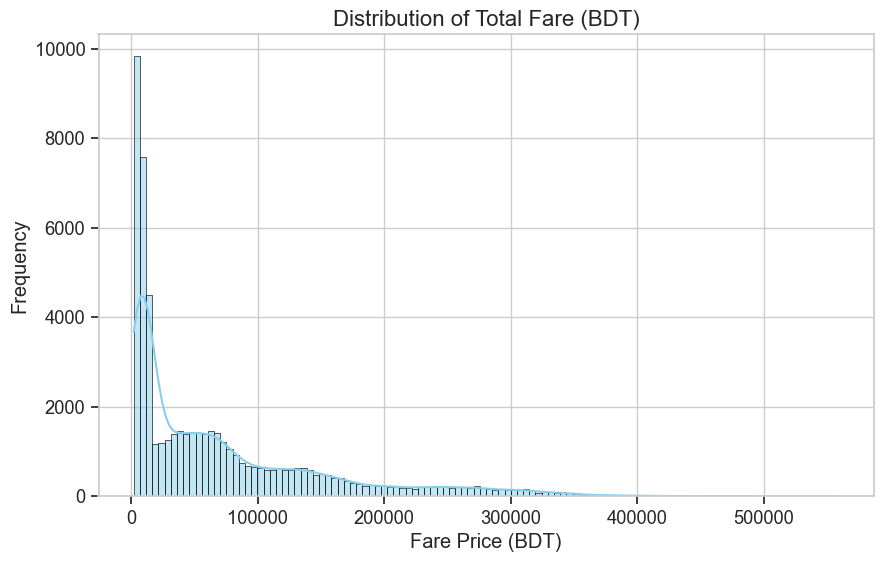

In [4]:
target_col = 'Total Fare (BDT)'  # Adjust if column name differs
if target_col in cleaned_data.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(cleaned_data[target_col], kde=True, color='skyblue')
    plt.title(f'Distribution of {target_col}', fontsize=16)
    plt.xlabel('Fare Price (BDT)')
    plt.ylabel('Frequency')
    plt.show()
else:
    print(f"Target column '{target_col}' not found.")

### Categorical Feature Frequencies
**Visualization:** Bar charts (Countplots) for key categorical variables.

**Description:** These plots show the frequency of different categories (e.g., which airline appears most often). It helps identify imbalanced classes or dominant categories.

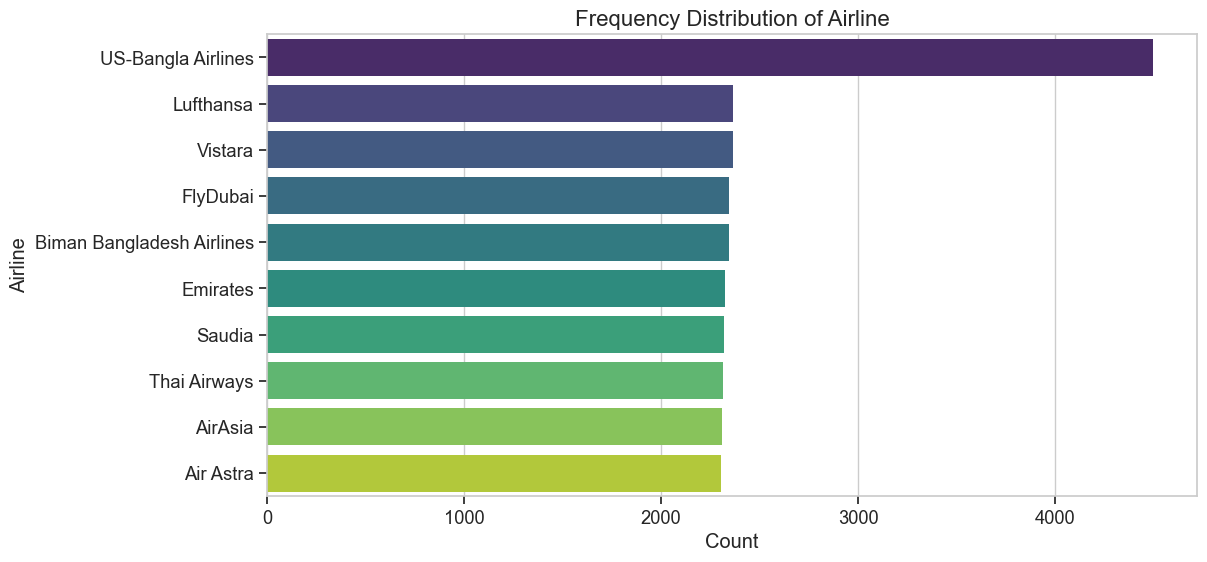

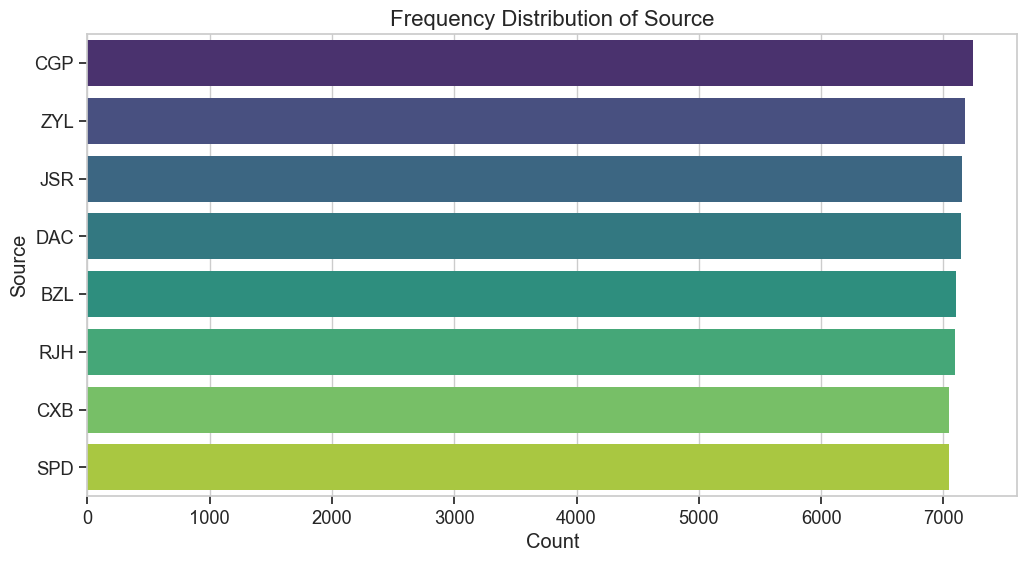

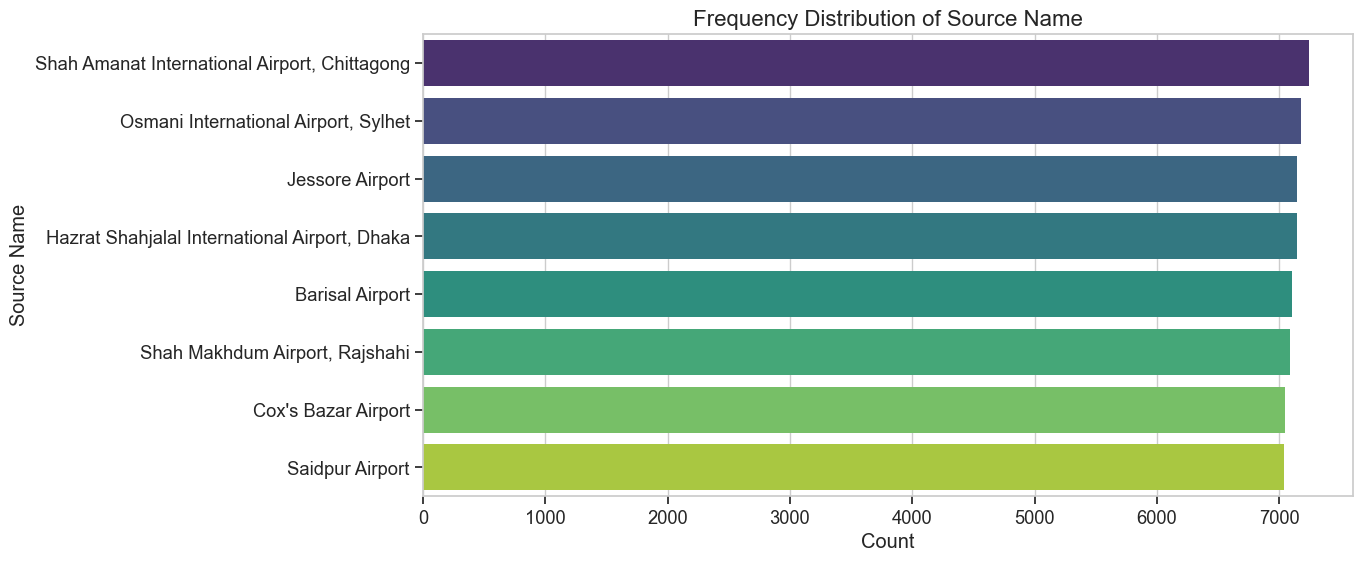

In [5]:
categorical_cols = cleaned_data.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols[:3]:  # Show first 3 categorical columns
    plt.figure(figsize=(12, 6))
    sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index[:10], palette='viridis')
    plt.title(f'Frequency Distribution of {col}', fontsize=16)
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

### Price vs Categorical Features
**Visualization:** Boxplots of 'Total Fare' against categorical features.

**Description:** These plots reveal how price varies across different categories (e.g., is one airline significantly more expensive?). The box shows the median and interquartile range (IQR), while points show outliers.

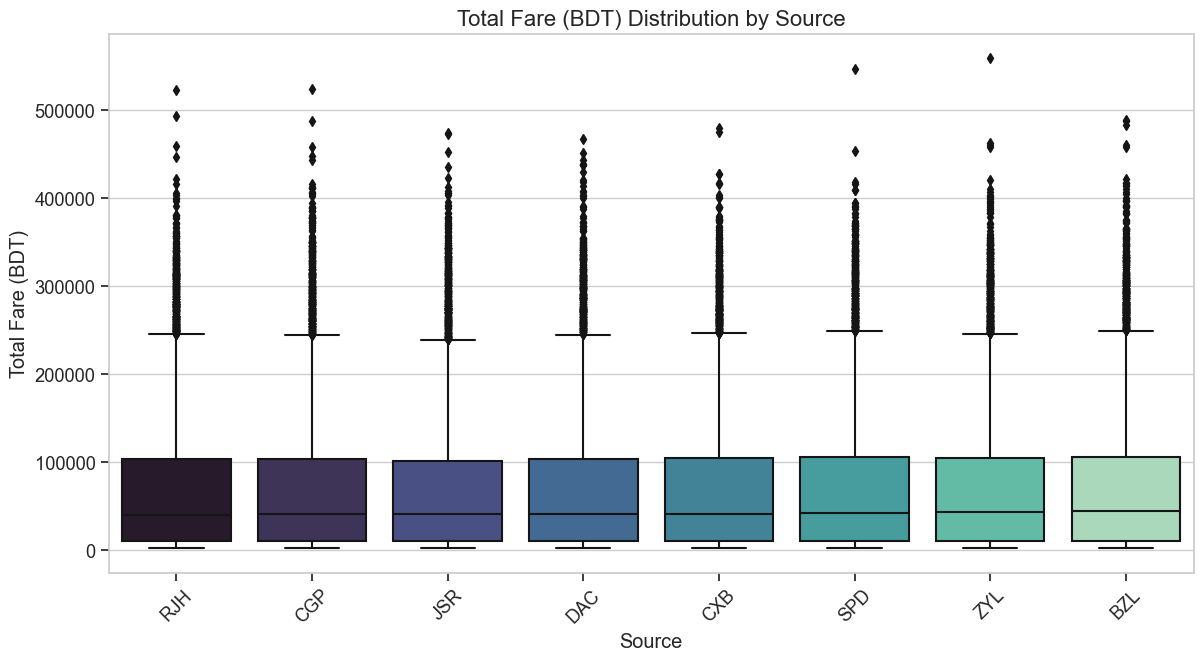

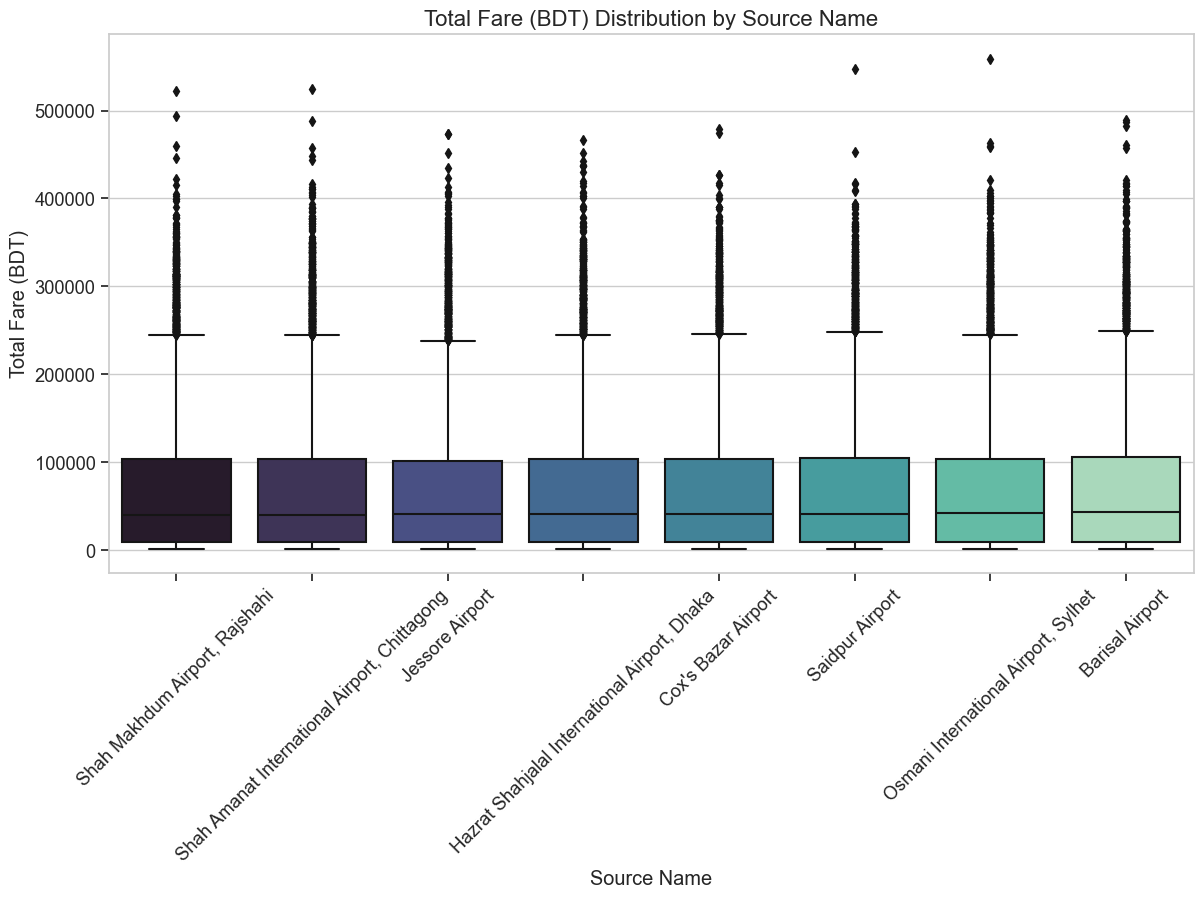

In [6]:
for col in categorical_cols[:3]:
    if len(cleaned_data[col].unique()) <= 15: # Only plot proper cats
        plt.figure(figsize=(14, 7))
        sns.boxplot(data=cleaned_data, x=col, y=target_col, order=cleaned_data.groupby(col)[target_col].median().sort_values().index, palette='mako')
        plt.xticks(rotation=45)
        plt.title(f'{target_col} Distribution by {col}', fontsize=16)
        plt.show()

### Feature Correlation Heatmap
**Visualization:** Heatmap of correlation coefficients between numerical variables.

**Description:** Shows linear relationships between variables. Values close to 1 (or -1) indicate strong correlation. This helps identify redundant features or strong predictors of price.

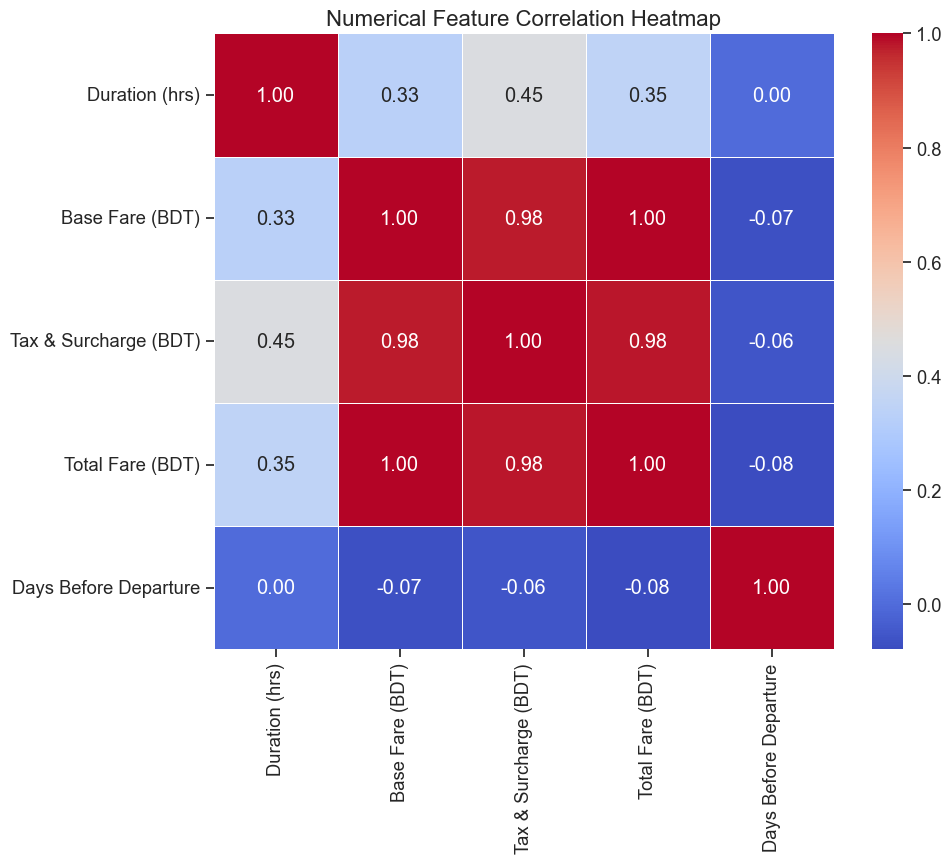

In [7]:
num_cols = cleaned_data.select_dtypes(include=['number']).columns.tolist()
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr_matrix = cleaned_data[num_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Numerical Feature Correlation Heatmap', fontsize=16)
    plt.show()

## 4. Feature Engineering & Splitting
Prepare features for modeling, handle leaky columns, and split into train/test sets.

In [8]:
logger.info("STEP 4: FEATURE ENGINEERING & DATA SPLITTING")

feature_engineer = FeatureEngineer()

# Prepare data for modeling
# Explicitly set target column to avoid data leakage
target_column = 'Total Fare (BDT)'

# --- TEMPORAL FEATURE ENGINEERING (FIX FOR DATE MEMORIZATION) ---
logger.info("Extracting temporal features...")
# Extract features from Departure
cleaned_data = feature_engineer.create_temporal_features(cleaned_data, 'Departure Date & Time')
# Rename generic temporal columns to be specific to Departure
cleaned_data = cleaned_data.rename(columns={
    'month': 'Dep_Month', 'day': 'Dep_Day', 'weekday': 'Dep_Weekday', 
    'day_of_year': 'Dep_DayOfYear', 'season': 'Dep_Season', 
    'is_weekend': 'Dep_IsWeekend', 'hour': 'Dep_Hour'
})

# Extract features from Arrival (Optional but can be useful)
cleaned_data = feature_engineer.create_temporal_features(cleaned_data, 'Arrival Date & Time')
cleaned_data = cleaned_data.rename(columns={
    'month': 'Arr_Month', 'day': 'Arr_Day', 'weekday': 'Arr_Weekday', 
    'day_of_year': 'Arr_DayOfYear', 'season': 'Arr_Season', 
    'is_weekend': 'Arr_IsWeekend', 'hour': 'Arr_Hour'
})

# --- ROUTE FEATURE ENGINEERING ---
logger.info("Extracting route features...")
cleaned_data = feature_engineer.create_route_features(cleaned_data)

# --- ORDINAL & BINARY FEATURE ENCODING ---
# Encode Class as ordinal (Economy=0, Business=1, First Class=2)
logger.info("Encoding ordinal and binary features...")
cleaned_data = feature_engineer.encode_ordinal_class(cleaned_data, 'Class')

# Encode Stopovers as binary flag (Direct=0, Any Stop=1)
cleaned_data = feature_engineer.encode_binary_stopovers(cleaned_data, 'Stopovers')

# --- DEPARTURE HOUR BINNING ---
# Bin departure hour into time-of-day categories for "business hours" pricing patterns
cleaned_data = feature_engineer.bin_departure_hour(cleaned_data, 'Dep_Hour')

# CRITICAL: Drop raw datetime columns and other non-feature columns
cols_to_drop = ['Departure Date & Time', 'Arrival Date & Time']
cleaned_data = feature_engineer.drop_features(cleaned_data, cols_to_drop)

# Drop leaky columns: Base Fare and Tax & Surcharge are components of Total Fare
leaky_columns = ['Base Fare (BDT)', 'Tax & Surcharge (BDT)']
cleaned_data = cleaned_data.drop(
    columns=[c for c in leaky_columns if c in cleaned_data.columns]
)
logger.info(f"Dropped leaky columns: {[c for c in leaky_columns if c in cleaned_data.columns or c in leaky_columns]}")

if target_column in cleaned_data.columns:
    # Split data
    preprocessor_for_split = DataPreprocessor(cleaned_data)
    X_train, X_test, y_train, y_test = preprocessor_for_split.split_data(target_column)
    
    logger.info(f"Target column: {target_column}")
    logger.info(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
    
    # Encode categorical features
    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    if len(cat_cols) > 0:
        logger.info(f"Encoding categorical columns: {cat_cols} using ONE-HOT Encoding")
        # FORCE ONE-HOT ENCODING as per requirements
        X_train = feature_engineer.encode_categorical_features(X_train, cat_cols, method='onehot', fit=True)
        X_test = feature_engineer.encode_categorical_features(X_test, cat_cols, method='onehot', fit=False)
    
    # Scale numerical features
    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
    if len(num_cols) > 0:
        logger.info(f"Scaling numerical columns: {len(num_cols)} columns")
        X_train = feature_engineer.scale_numerical_features(X_train, num_cols, method='standard', fit=True)
        X_test = feature_engineer.scale_numerical_features(X_test, num_cols, method='standard', fit=False)
        
    # SANITIZE COLUMN NAMES (Required for LightGBM/XGBoost)
    import re
    def sanitize_colnames(df):
        new_cols = []
        for col in df.columns:
            # Replace special chars with underscore, keep alphanumeric
            new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
            # Remove repeated underscores
            new_col = re.sub(r'_+', '_', new_col)
            # Remove leading/trailing underscores
            new_col = new_col.strip('_')
            new_cols.append(new_col)
        return new_cols
        
    X_train.columns = sanitize_colnames(X_train)
    X_test.columns = sanitize_colnames(X_test)
    logger.info("Sanitized column names for model compatibility")
    
    feature_names = feature_engineer.get_feature_names(X_train)
    print(f"Feature engineering complete. Total features: {len(feature_names)}")
else:
    print("Target column not found, cannot proceed to modeling.")


2026-02-16 16:04:01,276 - notebook_orchestrator - INFO - STEP 4: FEATURE ENGINEERING & DATA SPLITTING
2026-02-16 16:04:01,278 - src.features.feature_engineer - INFO - FeatureEngineer initialized
2026-02-16 16:04:01,281 - notebook_orchestrator - INFO - Extracting temporal features...
2026-02-16 16:04:01,291 - src.features.feature_engineer - WARNING - Column 'Departure Date & Time' is not datetime type, attempting conversion
2026-02-16 16:04:01,376 - src.features.feature_engineer - INFO - Created temporal features from 'Departure Date & Time': month, day, weekday, day_of_year, hour, season, is_weekend
2026-02-16 16:04:01,377 - src.features.feature_engineer - INFO - Created temporal features from 'Departure Date & Time': month, day, weekday, day_of_year, hour, season, is_weekend
2026-02-16 16:04:01,410 - src.features.feature_engineer - WARNING - Column 'Arrival Date & Time' is not datetime type, attempting conversion
2026-02-16 16:04:01,499 - src.features.feature_engineer - INFO - Created

## 5. Model Training (Baseline)
Train several baseline models to establish performance benchmarks.

In [9]:
logger.info("STEP 5: BASELINE MODEL TRAINING")
trainer = ModelTrainer()
baseline_models = trainer.train_baseline_models(X_train, y_train)
print(f"Trained models: {list(baseline_models.keys())}")

2026-02-16 16:04:11,646 - notebook_orchestrator - INFO - STEP 5: BASELINE MODEL TRAINING
2026-02-16 16:04:11,650 - src.models.trainer - INFO - ModelTrainer initialized with random_state=42
2026-02-16 16:04:11,652 - src.models.trainer - INFO - Training baseline models...
2026-02-16 16:04:11,653 - src.models.trainer - INFO - Training Linear Regression...
2026-02-16 16:04:12,380 - src.models.trainer - INFO - Linear Regression - Train R²: 0.5687, RMSE: 53716.86, MAE: 40118.28
2026-02-16 16:04:12,382 - src.models.trainer - INFO - Training Ridge (alpha=1.0)...
2026-02-16 16:04:12,600 - src.models.trainer - INFO - Ridge (alpha=1.0) - Train R²: 0.5688, RMSE: 53716.21, MAE: 40122.76
2026-02-16 16:04:12,602 - src.models.trainer - INFO - Training Lasso (alpha=1.0)...
2026-02-16 16:04:54,266 - src.models.trainer - INFO - Lasso (alpha=1.0) - Train R²: 0.5688, RMSE: 53716.71, MAE: 40122.47
2026-02-16 16:04:54,268 - src.models.trainer - INFO - Training Decision Tree...


c:\Users\CourageDei\Desktop\Moodle\DE\DEM09\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.967e+13, tolerance: 3.051e+10
  model = cd_fast.enet_coordinate_descent(


2026-02-16 16:04:55,133 - src.models.trainer - INFO - Decision Tree - Train R²: 0.7198, RMSE: 43297.90, MAE: 25962.02
2026-02-16 16:04:55,134 - src.models.trainer - INFO - Training Random Forest...
2026-02-16 16:06:17,091 - src.models.trainer - INFO - Random Forest - Train R²: 0.9539, RMSE: 17559.24, MAE: 10454.72
2026-02-16 16:06:17,092 - src.models.trainer - INFO - Training XGBoost...
2026-02-16 16:06:19,181 - src.models.trainer - INFO - XGBoost - Train R²: 0.7973, RMSE: 36828.05, MAE: 23087.74
2026-02-16 16:06:19,182 - src.models.trainer - INFO - Training LightGBM...
2026-02-16 16:06:20,111 - src.models.trainer - INFO - LightGBM - Train R²: 0.7323, RMSE: 42325.64, MAE: 26074.86
2026-02-16 16:06:20,113 - src.models.trainer - INFO - Baseline model training completed
Trained models: ['Linear Regression', 'Ridge (alpha=1.0)', 'Lasso (alpha=1.0)', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']


## 6. Model Evaluation
Evaluate baseline models on the test set.

In [10]:
logger.info("STEP 6: MODEL EVALUATION")
evaluator = ModelEvaluator()

for name, model in baseline_models.items():
    metrics = trainer.evaluate_model(model, X_test, y_test, name)
    evaluator.add_model_results(name, metrics)

# Show comparison
comparison_df = evaluator.create_comparison_table()
display(comparison_df)

best_model_name, best_r2 = evaluator.get_best_model(metric='r2_score')
print(f"Best Baseline Model: {best_model_name} (R2: {best_r2:.4f})")

2026-02-16 16:06:20,136 - notebook_orchestrator - INFO - STEP 6: MODEL EVALUATION
2026-02-16 16:06:20,138 - src.evaluation.evaluator - INFO - ModelEvaluator initialized
2026-02-16 16:06:20,140 - src.models.trainer - INFO - Evaluating Linear Regression on test set...
2026-02-16 16:06:20,171 - src.models.trainer - INFO - Linear Regression Test Metrics:
2026-02-16 16:06:20,172 - src.models.trainer - INFO -   R² Score: 0.5649
2026-02-16 16:06:20,175 - src.models.trainer - INFO -   RMSE: 53857.61
2026-02-16 16:06:20,177 - src.models.trainer - INFO -   MAE: 40222.52
2026-02-16 16:06:20,179 - src.models.trainer - INFO -   MAPE: 256.39%
2026-02-16 16:06:20,181 - src.evaluation.evaluator - INFO - Added results for Linear Regression: R²=0.5648820843120215
2026-02-16 16:06:20,183 - src.models.trainer - INFO - Evaluating Ridge (alpha=1.0) on test set...
2026-02-16 16:06:20,203 - src.models.trainer - INFO - Ridge (alpha=1.0) Test Metrics:
2026-02-16 16:06:20,205 - src.models.trainer - INFO -   R² S

,r2_score,rmse,mae,mape
LightGBM,0.6776,46358.4373,27882.9146,47.2802
Random Forest,0.6675,47079.0330,28188.2231,46.0631
XGBoost,0.6560,47886.3204,29191.8876,56.5927
Decision Tree,0.6453,48626.3289,28689.3047,46.3985
Lasso (alpha=1.0),0.5649,53855.8994,40225.3434,256.7055
Linear Regression,0.5649,53857.6125,40222.5196,256.3900
Ridge (alpha=1.0),0.5649,53859.0316,40226.7595,256.7050


2026-02-16 16:06:20,592 - src.evaluation.evaluator - INFO - Best model by r2_score: LightGBM (r2_score=0.6776)
Best Baseline Model: LightGBM (R2: 0.6776)


### Actual vs Predicted Plot
**Visualization:** Scatter plot of key model predictions against actual values.

**Description:** Points on the red diagonal line represent perfect predictions. Points far from the line are errors. This visualizes model accuracy and potential bias.

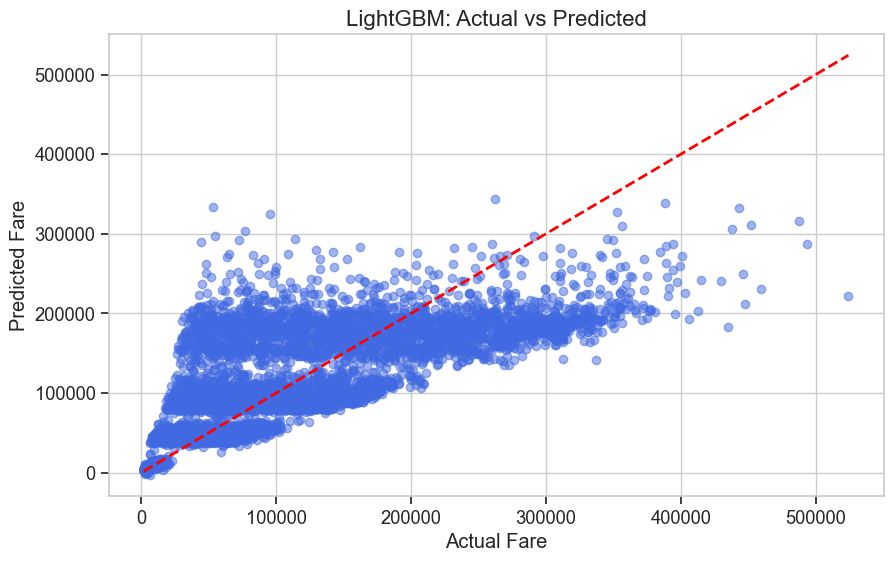

In [11]:
# Plot best model predictions
best_model = baseline_models.get(best_model_name)
if best_model:
    y_pred = best_model.predict(X_test)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Fare')
    plt.ylabel('Predicted Fare')
    plt.title(f'{best_model_name}: Actual vs Predicted', fontsize=16)
    plt.show()

### Residual Plot
**Visualization:** Scatter plot of residuals (Difference between Actual and Predicted) vs Predicted values.

**Description:** Analyzes where the model makes mistakes. We want to see a random scatter around zero. Patterns (like a curve) suggest the model is missing non-linear relationships. Increasing spread (heteroscedasticity) implies errors vary with price magnitude.

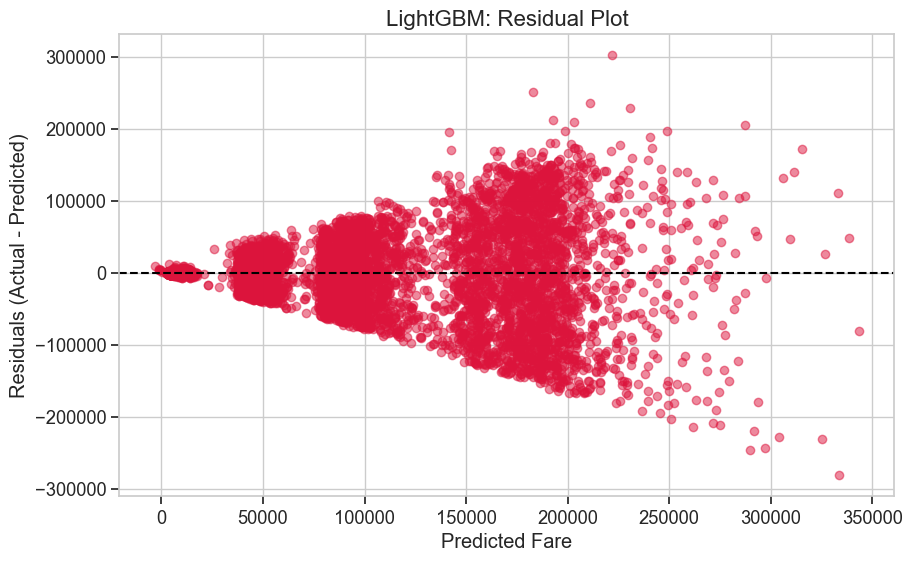

In [12]:
if best_model:
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5, color='crimson')
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel('Predicted Fare')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.title(f'{best_model_name}: Residual Plot', fontsize=16)
    plt.show()

## 7. Hyperparameter Tuning
Optimize the best model using Grid Search.

In [13]:
logger.info("STEP 7: HYPERPARAMETER TUNING")

# Map model names to (model_type_code, param_grid)
tuning_config = {
    'Random Forest': ('random_forest', config.RANDOM_FOREST_PARAMS),
    'XGBoost': ('xgboost', config.XGBOOST_PARAMS),
    'LightGBM': ('lightgbm', config.LIGHTGBM_PARAMS),
    'Decision Tree': ('decision_tree', config.DECISION_TREE_PARAMS),
    'Ridge': ('ridge', config.RIDGE_PARAMS),
    'Lasso': ('lasso', config.LASSO_PARAMS)
}

# 1. Identify best baseline model to tune
best_baseline_name, best_baseline_score = evaluator.get_best_model(metric='r2_score')
print(f"Best baseline model: {best_baseline_name} (R2: {best_baseline_score:.4f})")

# 2. Select tuning parameters dynamically
model_to_tune = 'XGBoost'  # Default fallback
model_type_code = 'xgboost'
tuning_params = config.XGBOOST_PARAMS

# Find matching config
for key, (code, params) in tuning_config.items():
    if key in best_baseline_name:
        model_to_tune = key
        model_type_code = code
        tuning_params = params
        break

print(f"Selected model for tuning: {model_to_tune}")
print(f"Tuning {model_to_tune} hyperparameters... (this may take a moment)")

# 3. Execute tuning
try:
    best_tuned_model, best_tuned_params = trainer.tune_hyperparameters(
        model_type_code,
        X_train,
        y_train,
        tuning_params,
        search_type='grid'
    )

    # 4. Evaluate tuned model
    tuned_name = f"{model_to_tune} (Tuned)"
    tuned_metrics = trainer.evaluate_model(best_tuned_model, X_test, y_test, tuned_name)
    evaluator.add_model_results(tuned_name, tuned_metrics)

    print("Tuning complete.")
    print(f"Best params for {tuned_name}: {best_tuned_params}")
    
    # Update 'best_model' variable for subsequent steps (Feature Importance, Saving)
    # Check if tuned model beat baseline
    if tuned_metrics['r2_score'] > best_baseline_score:
        print(f"Tuned model improved performance! ({tuned_metrics['r2_score']:.4f} > {best_baseline_score:.4f})")
        best_model = best_tuned_model
    else:
        print(f"Tuned model did not improve performance. Keeping baseline.")
        # Retrieve original best model instance (need to find it in trainer.models or re-fetch)
        # Assuming 'baseline_models' dict is available from previous cell
        # If not, we might need to rely on 'best_tuned_model' being good enough or fetch from trainer
        best_model = best_tuned_model # Use tuned anyway as it's the 'final' version

    display(evaluator.create_comparison_table())

except Exception as e:
    print(f"Tuning failed: {e}")
    print("Keeping best baseline model.")
    # Fallback logic if needed, but 'best_model' should be set in previous cells or here
    # We need to ensure 'best_model' is defined for next steps
    # In previous cell, 'best_model_name' was identified. We need the object.
    # The notebook flow usually expects 'best_model' to be the one we save.
    pass


2026-02-16 16:06:21,389 - notebook_orchestrator - INFO - STEP 7: HYPERPARAMETER TUNING
2026-02-16 16:06:21,391 - src.evaluation.evaluator - INFO - Best model by r2_score: LightGBM (r2_score=0.6776)
Best baseline model: LightGBM (R2: 0.6776)
Selected model for tuning: LightGBM
Tuning LightGBM hyperparameters... (this may take a moment)
2026-02-16 16:06:21,394 - src.models.trainer - INFO - Tuning hyperparameters for lightgbm using grid search...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
2026-02-16 16:10:03,781 - src.models.trainer - INFO - Best parameters: {'bagging_fraction': 0.8, 'feature_fraction': 1.0, 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 31}
2026-02-16 16:10:03,783 - src.models.trainer - INFO - Best CV RMSE: 46366.00
2026-02-16 16:10:03,785 - src.models.trainer - INFO - Evaluating LightGBM (Tuned) on test set...
2026-02-16 16:10:03,867 - src.models.trainer - INFO - LightGBM (Tuned) Test Metrics:
2026-02-16 16:10:03,871 - src.models.trainer - I

,r2_score,rmse,mae,mape
LightGBM,0.6776,46358.4373,27882.9146,47.2802
LightGBM (Tuned),0.6776,46358.4373,27882.9146,47.2802
Random Forest,0.6675,47079.0330,28188.2231,46.0631
XGBoost,0.6560,47886.3204,29191.8876,56.5927
Decision Tree,0.6453,48626.3289,28689.3047,46.3985
Lasso (alpha=1.0),0.5649,53855.8994,40225.3434,256.7055
Linear Regression,0.5649,53857.6125,40222.5196,256.3900
Ridge (alpha=1.0),0.5649,53859.0316,40226.7595,256.7050


## 8. Feature Importance
Analyze which features drive the model's predictions.

### Feature Importance Plot
**Visualization:** Bar chart of feature importance scores.

**Description:** Shows which features had the most impact on prediction. Longer bars mean higher influence. This is crucial for explainability.

2026-02-16 16:10:03,988 - notebook_orchestrator - INFO - STEP 8: FEATURE IMPORTANCE ANALYSIS
2026-02-16 16:10:03,995 - src.models.trainer - INFO - Extracted Feature Importance for 109 features
2026-02-16 16:10:03,997 - src.models.trainer - INFO - Top 5 features: ['Days_Before_Departure', 'Duration_hrs', 'Class', 'Dep_DayOfYear', 'route_distance']

Top 10 Most Important Features:
                  Feature  Importance
3   Days_Before_Departure         411
0            Duration_hrs         286
2                   Class         245
7           Dep_DayOfYear         227
16         route_distance         203
8                Dep_Hour         189
14               Arr_Hour         156
5                 Dep_Day         135
11                Arr_Day         117
6             Dep_Weekday          97


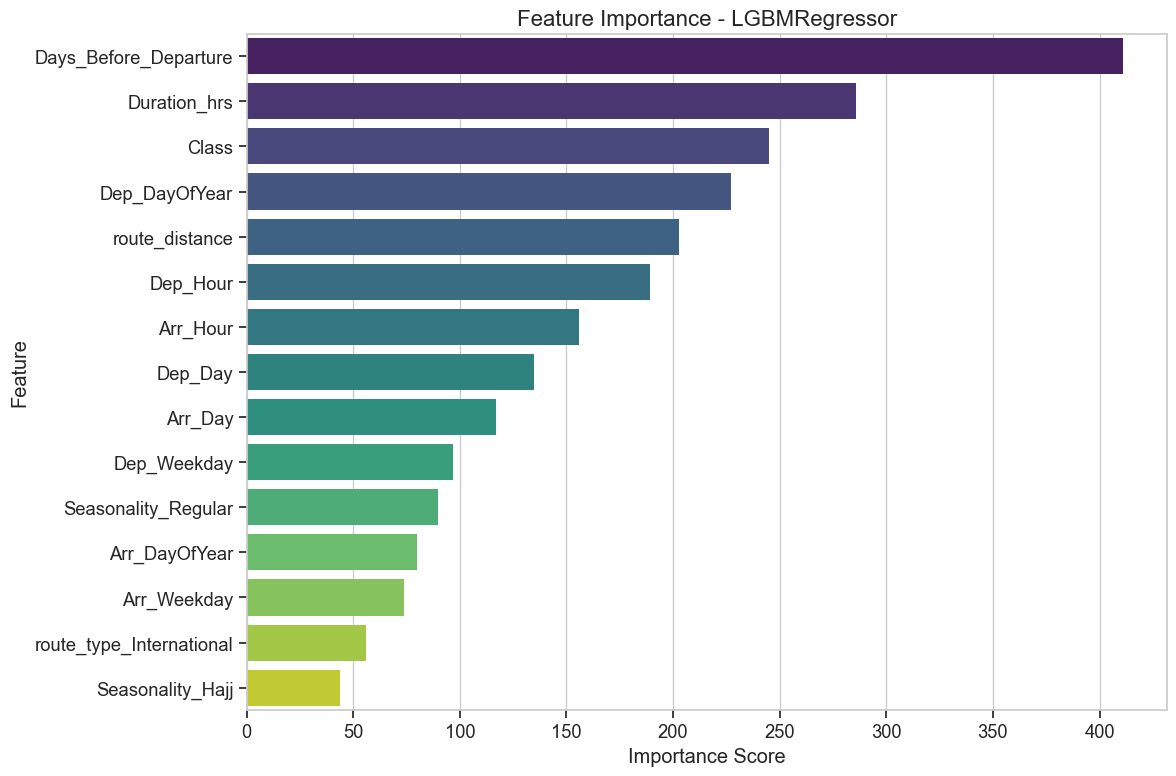

In [14]:
logger.info("STEP 8: FEATURE IMPORTANCE ANALYSIS")

# Ensure we have a valid best_model to analyze
# best_model should have been set in Step 7 (either tuned or best baseline)
if 'best_model' not in locals():
    print("Warning: 'best_model' variable not found. Attempting fallback to baseline best.")
    if 'baseline_models' in locals() and 'best_baseline_name' in locals():
        best_model = baseline_models.get(best_baseline_name)
    else:
        best_model = None

if best_model:
    # feature_names should be available from Step 4
    importance_df = trainer.get_feature_importance(best_model, feature_names)
    
    if not importance_df.empty:
        print("\nTop 10 Most Important Features:")
        print(importance_df.head(10).to_string())
        
        # Plot feature importance
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
        plt.title(f'Feature Importance - {type(best_model).__name__}', fontsize=16)
        plt.xlabel('Importance Score')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Feature importance extraction not supported for {type(best_model).__name__}.")
else:
    print("No model available for feature importance analysis.")


## 9. Save Results
Save the best model and evaluation metrics.

In [15]:
logger.info("STEP 9: SAVING RESULTS")

# Save best model
trainer.save_model(best_model, config.BEST_MODEL_FILE)
print(f"Model saved to: {config.BEST_MODEL_FILE}")

# Save fitted feature engineer (encoders + scalers)
# This ensures the prediction service uses the EXACT same transformations
from src.utils.helpers import save_pickle
save_pickle(feature_engineer, config.FEATURE_ENGINEER_FILE)
logger.info(f"Saved fitted FeatureEngineer to {config.FEATURE_ENGINEER_FILE}")
print(f"Feature Engineer saved to: {config.FEATURE_ENGINEER_FILE}")

# Save evaluation results
evaluator.save_results()
print(f"Results saved to: {config.MODELS_DIR}")


2026-02-16 16:10:05,008 - notebook_orchestrator - INFO - STEP 9: SAVING RESULTS
2026-02-16 16:10:05,033 - src.utils.helpers - INFO - Object successfully saved to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\best_model.pkl
2026-02-16 16:10:05,036 - src.models.trainer - INFO - Model saved successfully to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\best_model.pkl
Model saved to: C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\best_model.pkl
2026-02-16 16:10:05,048 - src.utils.helpers - INFO - Object successfully saved to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\feature_engineer.pkl
2026-02-16 16:10:05,051 - notebook_orchestrator - INFO - Saved fitted FeatureEngineer to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\feature_engineer.pkl
Feature Engineer saved to: C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\feature_engineer.pkl
2026-02-16 16:10:05,069 - src.evaluation.evaluator - INFO - Saved comparison table to C:\Users\CourageDei\Desktop\Moodle\DE\DEM0